# Leitura

In [2]:
import pandas as pd

arquivo = "/content/diabetes_012_health_indicators_BRFSS2015 (1).csv"
df_puro = pd.read_csv(arquivo)

# Visualização de dados e Tratamento

In [3]:
df_tratado = df_puro.copy()

In [4]:
print(df_tratado.head())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

In [5]:
print(df_tratado.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
print(df_tratado.describe(include="all"))

        Diabetes_012         HighBP       HighChol      CholCheck  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.296921       0.429001       0.424121       0.962670   
std         0.698160       0.494934       0.494210       0.189571   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       1.000000       1.000000       1.000000   
max         2.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        12.000000       0.000000       0.000000              0.000000  

In [7]:
df_tratado.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [8]:
#df_puro.dropna(inplace=True)

In [9]:
df_tratado.duplicated().sum()

np.int64(23899)

In [10]:
df_tratado.drop_duplicates(inplace=True)

# Plotagens para melhores visualizações

* BMI (Índice de Massa Corporal)

* MentHlth (Saúde mental ruim)

* PhysHlth (Saúde física ruim)






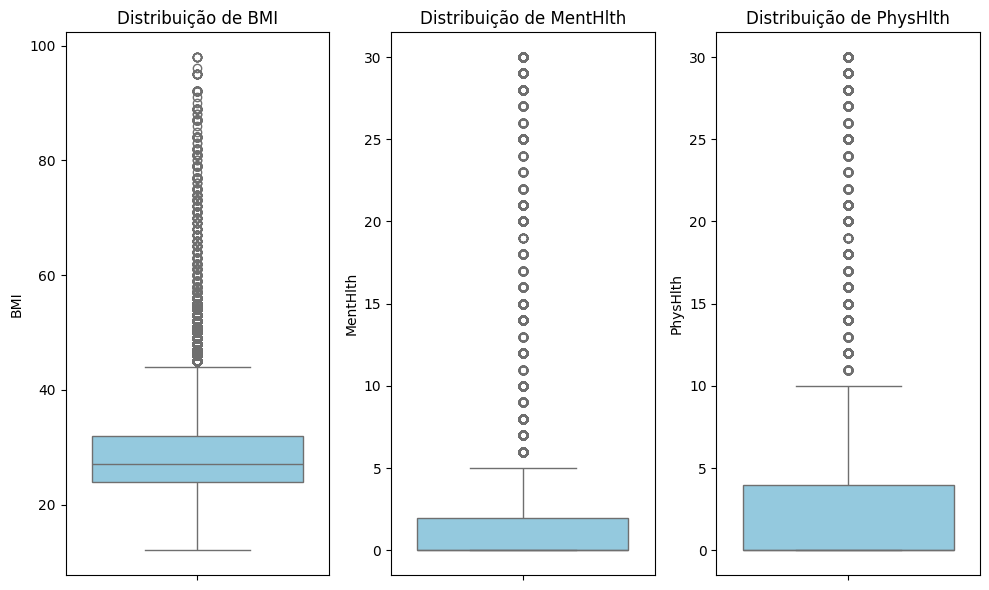

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for i, col in enumerate(["BMI", "MentHlth","PhysHlth"],1):
  plt.subplot(1,3,i)
  sns.boxplot(y=df_tratado[col],color="skyblue")
  plt.title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()

<ipython-input-12-459cdb99d4ec>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_tratado["Diabetes_012"],palette="pastel")


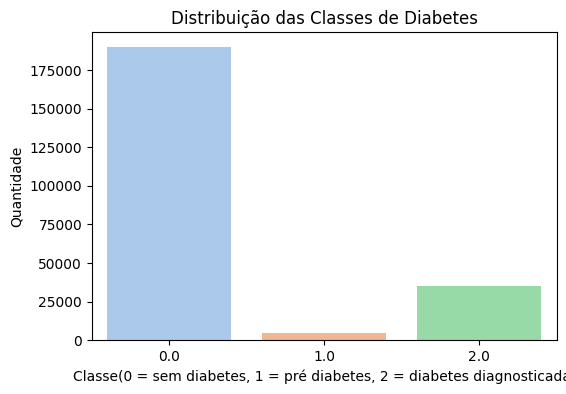

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_tratado["Diabetes_012"],palette="pastel")
plt.title("Distribuição das Classes de Diabetes")
plt.xlabel("Classe(0 = sem diabetes, 1 = pré diabetes, 2 = diabetes diagnosticada)")
plt.ylabel("Quantidade")
plt.show()



1.   O dataset está fortemente desbalanceado.
2.   Muitos valores extremos (outliers) em colunas como BMI, MentHlth, PhysHlth.



# Tratamento de Outliers - IQR

In [14]:
#erro de tratamento na segunda coluna
# Cópia tratada

df_tratado = df_puro.drop_duplicates().copy()

# Função para obter filtro IQR sem aplicar direto
def filtro_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)

# Aplicar filtros individualmente
filtro_bmi = filtro_iqr(df_tratado, "BMI")
filtro_ment = filtro_iqr(df_tratado, "MentHlth")
filtro_phys = filtro_iqr(df_tratado, "PhysHlth")

# Combinar os 3 filtros
filtro_geral = filtro_bmi & filtro_ment & filtro_phys

# Aplicar o filtro combinado de uma vez
df_tratado = df_tratado[filtro_geral]


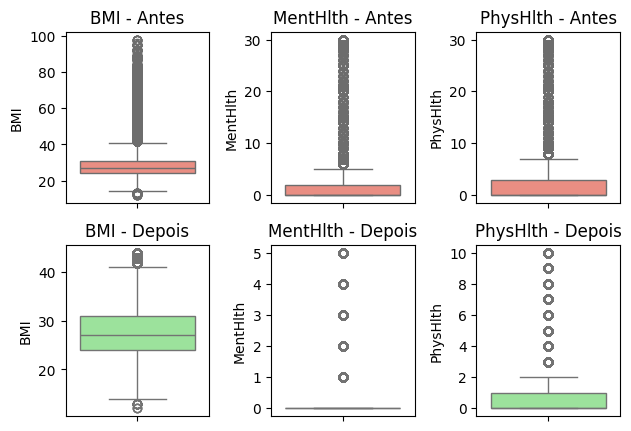

In [15]:
for i, col in enumerate(["BMI", "MentHlth", "PhysHlth"]):
    # Antes
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_puro[col], color="salmon")
    plt.title(f"{col} - Antes")

    # Depois
    plt.subplot(2, 3, i + 4)
    sns.boxplot(y=df_tratado[col], color="lightgreen")
    plt.title(f"{col} - Depois")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [16]:
df_tratado["MentHlth"].value_counts().sort_index()

,count
MentHlth,
0.0,134646
1.0,7663
2.0,11111
3.0,6311
4.0,3227
5.0,7093


In [18]:
df_tratado["BMI"].value_counts().sort_index()

,count
BMI,
12.0,3
13.0,14
14.0,23
15.0,75
16.0,222
17.0,505
18.0,1217
19.0,2689
20.0,4200


In [19]:
df_tratado["PhysHlth"].value_counts().sort_index()

,count
PhysHlth,
0.0,122821
1.0,9777
2.0,12251
3.0,6808
4.0,3559
5.0,5884
6.0,973
7.0,3386
8.0,578


In [20]:
df_tratado["Diabetes_012"].value_counts().sort_index()

,count
Diabetes_012,
0.0,145182
1.0,3090
2.0,21779


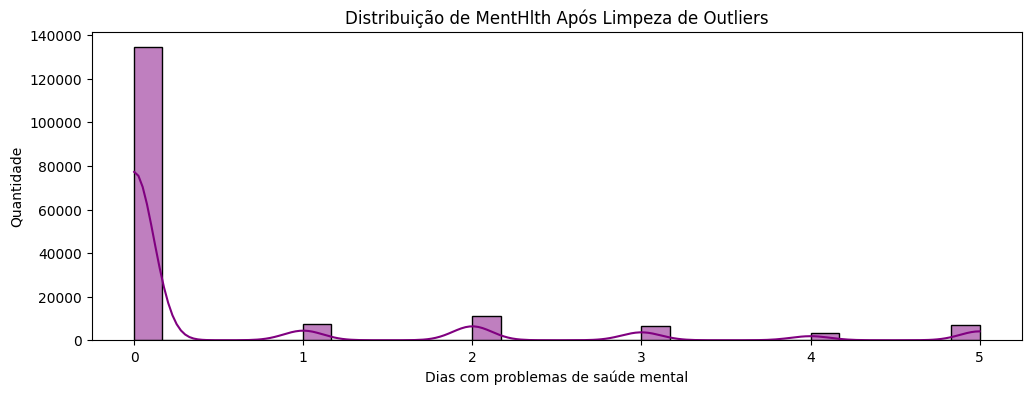

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.histplot(df_tratado["MentHlth"], bins=30, kde=True, color='purple')
plt.title("Distribuição de MentHlth Após Limpeza de Outliers")
plt.xlabel("Dias com problemas de saúde mental")
plt.ylabel("Quantidade")
plt.show()


# Balanceamento de Classes - Smote

In [21]:
!pip install imbalanced-learn


In [22]:
from imblearn.over_sampling import SMOTE
